In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../")

from oxels.augmentation import (
    HueShift, 
    MotionBlur, 
    KernelConvolution, 
    BrightnessContrast, 
    PixelNoise, 
    Sobel, 
    Scharr, 
    SequentialStrategy
)

In [2]:
#"harmless" augmentations
basic_augmentations = SequentialStrategy(
    [MotionBlur(), HueShift(), BrightnessContrast()],
    probabilities=[0.8,0.8,0.8],
    ordered=False,
    at_most_one=False)

#more disruptive augmentations that should be applied sparsingly and collide with one another
advanced_agumentation = SequentialStrategy(
    [KernelConvolution(), Sobel(), Scharr(), PixelNoise()],
    probabilities=None,
    ordered=False,
    at_most_one=True)

#all augmentations (order matters)
all_agumentations = SequentialStrategy(
    [basic_augmentations, advanced_agumentation],
    probabilities=[1.0, 0.2],
    ordered=True,
    at_most_one=False)

In [3]:
im = np.load("../../telescope/validation_data/Screencastfrom05-13-2024045817PM.webm/153_99_4_1.02105_0.15949_-0.11547_0.64957_-0.22244_-0.13525.npy")

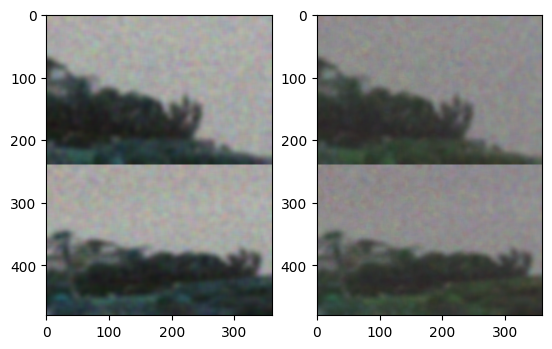

In [5]:
plt.subplot(121)
plt.imshow(im)
plt.subplot(122)
plt.imshow(all_agumentations(im))